In [1]:
import pandas as pd

csv_path = "/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/birds_embeddings_birdnet_padded_3s_model.csv"
df = pd.read_csv(csv_path)
df

,calltype,GopherSnake,Rattlesnake,ScrubJay,GroundSquirrel,Cowbird,SongSparrow,Model,file_id,file,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,D,1,0,0,0,0,0,GopherSnake,SL07_Trial_1_trim,/home/Shelby/blackbird_calls/Experiments/Detec...,...,0.000000,0.000000,0.283043,0.353124,0.850524,0.342322,0.000000,1.061636,0.762078,0.485685
1,F,1,0,0,0,0,0,GopherSnake,SL17a_Trial_1_trim,/home/Shelby/blackbird_calls/Experiments/Detec...,...,0.000000,0.000000,0.565755,0.272597,0.313492,0.231603,0.067483,1.466044,1.240883,0.785682
2,F,0,1,0,0,0,0,Rattlesnake,SL10_Trial_1_trim,/home/Shelby/blackbird_calls/Experiments/Detec...,...,0.007743,0.083630,0.350261,0.338610,0.525507,0.445224,0.000000,0.847136,0.351975,0.716970
3,Cheer,0,1,0,0,0,0,Rattlesnake,SL10_Trial_1_trim,/home/Shelby/blackbird_calls/Experiments/Detec...,...,0.250644,0.000000,0.057046,0.103796,1.025722,0.991909,0.000000,0.515161,0.025441,1.636110
4,Check,0,0,1,0,0,0,ScrubJay,AZ13_Trial_3_trim,/home/Shelby/blackbird_calls/Experiments/Detec...,...,0.000000,0.000597,1.142428,0.817335,0.477512,0.280269,0.000000,2.258079,0.730854,0.299776
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6042,Check,0,0,0,1,0,0,GroundSquirrel,SL52_Trial_1_trim,/home/Shelby/blackbird_calls/Experiments/Detec...,...,0.000000,0.000000,0.458764,0.260673,0.779880,0.335959,0.000000,1.328580,0.665761,0.626578
6043,K,0,0,1,0,0,0,ScrubJay,SL52_Trial_2_trim,/home/Shelby/blackbird_calls/Experiments/Detec...,...,0.000000,0.048159,0.047531,0.064807,0.008464,0.931550,0.000000,0.954245,0.235279,1.080495
6044,Check,0,0,0,0,0,1,SongSparrow,SL38_Trial_2_trim,/home/Shelby/blackbird_calls/Experiments/Detec...,...,0.000000,0.000000,1.012889,0.316343,1.167196,0.529842,0.000000,1.904490,0.844413,0.330008
6045,Chits,1,0,0,0,0,0,GopherSnake,SL40_Trial_2_trim,/home/Shelby/blackbird_calls/Experiments/Detec...,...,0.484483,0.000000,0.049928,0.000000,0.818705,0.544184,0.000000,0.432003,0.000000,0.481858


Dimentionality reduction via UMAP

In [21]:
import pandas as pd
import numpy as np
import umap
import matplotlib.pyplot as plt

# Load the CSV with embeddings and calltype
csv_path = "/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/birds_embeddings_birdnet_padded_3s_model.csv"
df = pd.read_csv(csv_path)

print(f"Loaded data with shape: {df.shape}")
print(f"Columns: {df.columns.tolist()[:5]}...")  # Show first 5 columns

# Separate metadata from embeddings
# Assuming 'calltype' and 'file' are metadata columns, rest are embeddings
metadata_cols = ['calltype', 'Model', 'file_id', 'file', 'start_time', 'end_time']
embedding_cols = [col for col in df.columns if col not in metadata_cols]

print(f"\nNumber of embedding features: {len(embedding_cols)}")

# Extract embeddings as numpy array
X = df[embedding_cols].values
y = df['calltype'].values

# Run UMAP
print("\nRunning UMAP...")
reducer = umap.UMAP(n_components=5, random_state=42, n_neighbors=15, min_dist=0.5)
X_umap = reducer.fit_transform(X)

print("UMAP transformation complete!")

# Create a DataFrame with UMAP results
umap_df = pd.DataFrame({
    'UMAP1': X_umap[:, 0],
    'UMAP2': X_umap[:, 1],
    'UMAP3': X_umap[:, 2],
    'calltype': y
})

Loaded data with shape: (6047, 1036)
Columns: ['calltype', 'GopherSnake', 'Rattlesnake', 'ScrubJay', 'GroundSquirrel']...

Number of embedding features: 1030

Running UMAP...


/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



UMAP transformation complete!


Visualize clusters (2D UMAP)

In [22]:
import hdbscan

# Run HDBSCAN on the UMAP-reduced embeddings
print("Running HDBSCAN clustering...")
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5,      # Minimum samples in a cluster
    min_samples=3,            # Minimum samples in neighborhood
    metric='euclidean',
    cluster_selection_epsilon=0.0,
    cluster_selection_method='eom'
)

# Fit the clusterer
cluster_labels = clusterer.fit_predict(X_umap)

# Add cluster labels to the dataframe
df['cluster'] = cluster_labels

print(f"Clustering complete!")
print(f"Number of clusters found: {len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)}")
print(f"Number of noise points: {sum(cluster_labels == -1)}")
print(f"Cluster distribution:\n{pd.Series(cluster_labels).value_counts().sort_index()}")

Running HDBSCAN clustering...
Clustering complete!
Number of clusters found: 9
Number of noise points: 1
Cluster distribution:
-1       1
 0      17
 1    5912
 2      37
 3      17
 4      21
 5       5
 6       6
 7      19
 8      12
Name: count, dtype: int64


/tmp/ipykernel_506963/607420838.py:17: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



Compare clusters with ground truth call types

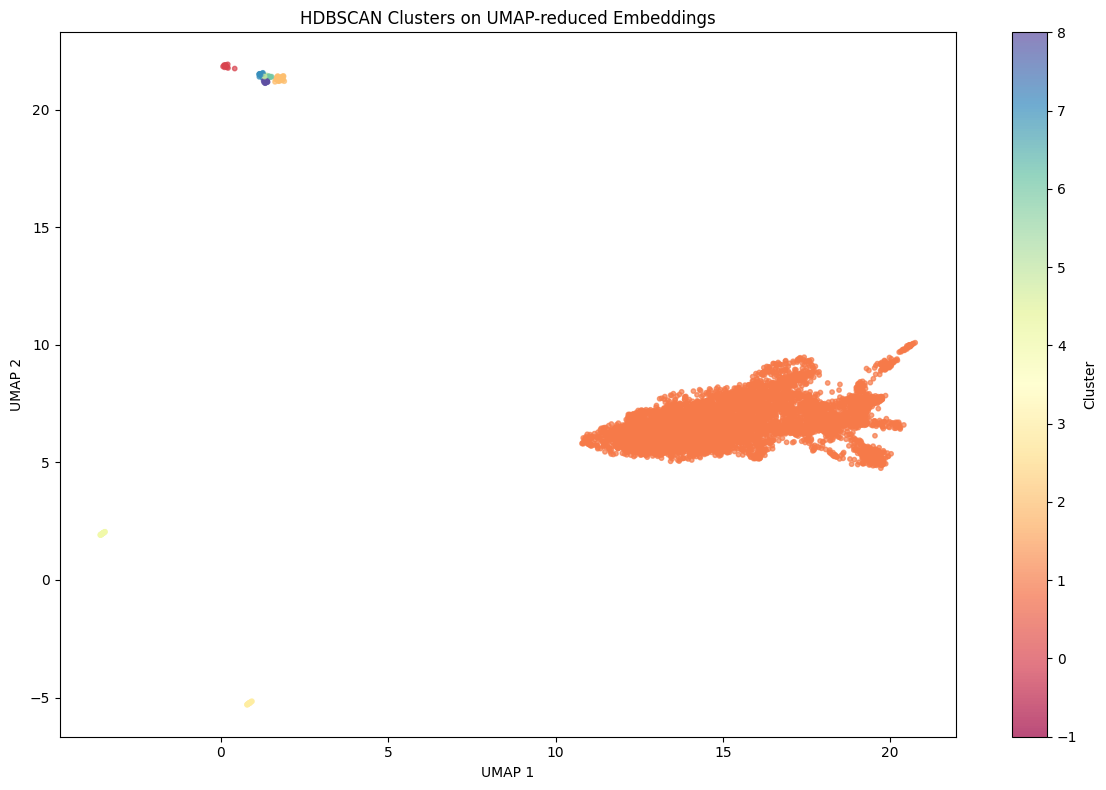

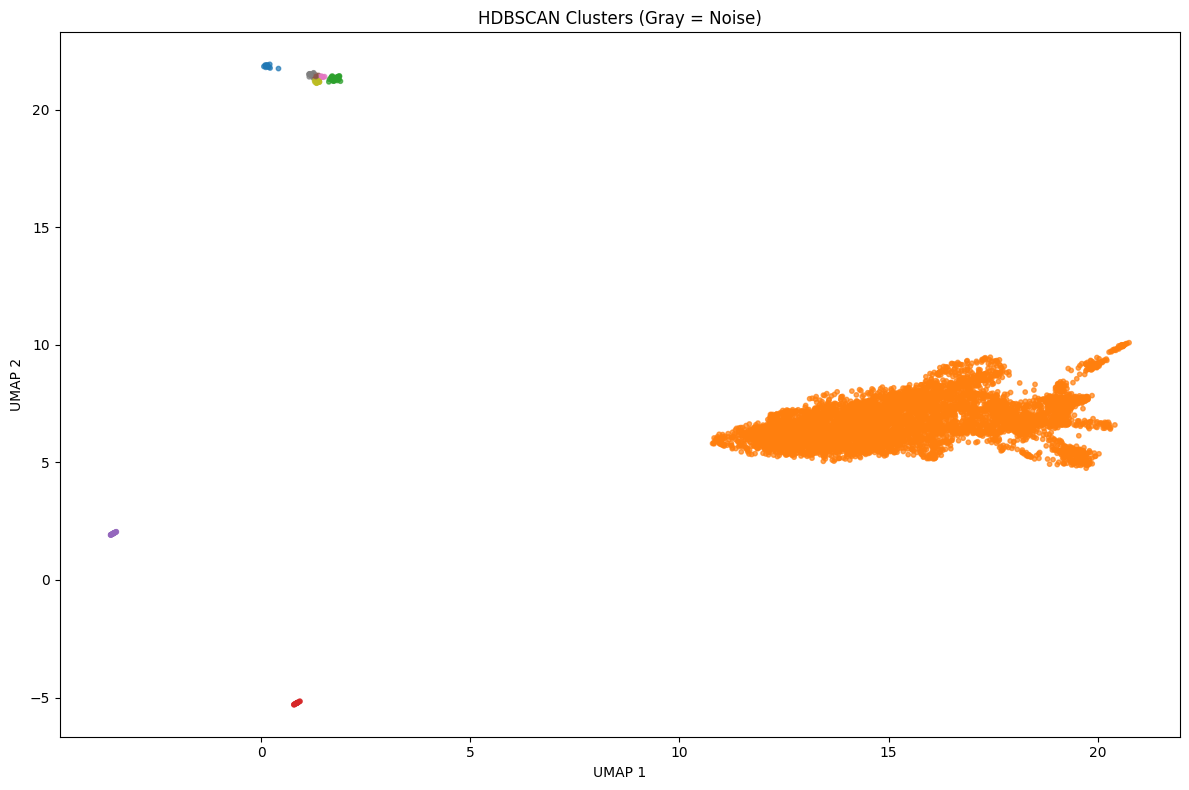

In [23]:
# Visualize clusters in 2D UMAP space
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    X_umap[:, 0], 
    X_umap[:, 1], 
    c=cluster_labels, 
    cmap='Spectral',
    s=10,
    alpha=0.7
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('HDBSCAN Clusters on UMAP-reduced Embeddings')
plt.tight_layout()
plt.show()

# Noise points in gray
plt.figure(figsize=(12, 8))
colors = ['gray' if label == -1 else f'C{label % 10}' for label in cluster_labels]
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=colors, s=10, alpha=0.7)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('HDBSCAN Clusters (Gray = Noise)')
plt.tight_layout()
plt.show()

In [20]:
import plotly.graph_objects as go
import plotly.express as px

# Create interactive 3D scatter plot with Plotly for UMAP embeddings
# Prepare data using first 3 UMAP components
plot_df = pd.DataFrame({
    'UMAP1': X_umap[:, 0],
    'UMAP2': X_umap[:, 1],
    'UMAP3': X_umap[:, 2],
    'Cluster': cluster_labels,
    'Call Type': y,
    'Probability': clusterer.probabilities_,
    'Outlier Score': clusterer.outlier_scores_
})

# Create color mapping (use discrete colors for clusters)
fig = go.Figure()

# Plot each cluster separately for better legend
unique_clusters = sorted(plot_df['Cluster'].unique())
colors = px.colors.qualitative.Plotly + px.colors.qualitative.Set2

for i, cluster in enumerate(unique_clusters):
    cluster_data = plot_df[plot_df['Cluster'] == cluster]
    
    # Gray for noise, colors for clusters
    if cluster == -1:
        color = 'gray'
        name = 'Noise'
    else:
        color = colors[cluster % len(colors)]
        name = f'Cluster {cluster}'
    
    fig.add_trace(go.Scatter3d(
        x=cluster_data['UMAP1'],
        y=cluster_data['UMAP2'],
        z=cluster_data['UMAP3'],
        mode='markers',
        name=name,
        marker=dict(
            size=3,
            color=color,
            opacity=0.7,
            line=dict(width=0)
        ),
        text=[f"Call Type: {ct}<br>Cluster: {c}<br>Probability: {p:.3f}" 
              for ct, c, p in zip(cluster_data['Call Type'], 
                                  cluster_data['Cluster'], 
                                  cluster_data['Probability'])],
        hovertemplate='<b>%{text}</b><br>UMAP1: %{x:.2f}<br>UMAP2: %{y:.2f}<br>UMAP3: %{z:.2f}<extra></extra>'
    ))

fig.update_layout(
    title='Interactive 3D HDBSCAN Clusters on UMAP (Click and Drag to Rotate)',
    scene=dict(
        xaxis_title='UMAP 1',
        yaxis_title='UMAP 2',
        zaxis_title='UMAP 3',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.5)
        )
    ),
    width=1000,
    height=800,
    showlegend=True
)

fig.show()

### Cluster Probabilities and Outlier Scores

In [67]:
# Cross-tabulation of clusters vs call types
print("Cross-tabulation of Clusters vs Call Types:")
crosstab = pd.crosstab(df['cluster'], df['calltype'], margins=True)
print(crosstab)

# Calculate purity metrics
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, homogeneity_completeness_v_measure

# Filter out noise points for some metrics
non_noise_mask = cluster_labels != -1
if sum(non_noise_mask) > 0:
    ari = adjusted_rand_score(y[non_noise_mask], cluster_labels[non_noise_mask])
    nmi = normalized_mutual_info_score(y[non_noise_mask], cluster_labels[non_noise_mask])
    homogeneity, completeness, v_measure = homogeneity_completeness_v_measure(y[non_noise_mask], cluster_labels[non_noise_mask])
    
    print(f"\n--- Clustering Quality Metrics (excluding noise) ---")
    print(f"Adjusted Rand Index: {ari:.3f}")
    print(f"Normalized Mutual Information: {nmi:.3f}")
    print(f"Homogeneity: {homogeneity:.3f}")
    print(f"Completeness: {completeness:.3f}")
    print(f"V-measure: {v_measure:.3f}")

Cross-tabulation of Clusters vs Call Types:
calltype   A    B    C  Check  Cheer  Chits    D    E    F   G  Growl   H   I  \
cluster                                                                         
0          0    0    0     26      5      4    0    1    2   1      0   0   5   
1          0    0    0     19      5      2    0    0    1   3      0   0   2   
2          0    0    0     15      7      1    0    1    0   2      0   0   1   
3          0    0    0      0      0      0    0    0    0   0      0   0  14   
4          0    1    0     18      3      2    0    0    0   2      0   0   3   
5          0   21    0      0      0      0    0    0    0   0      0   0   0   
6         20  114  202   3571    687    153  201  246  253  69      5  14  50   
All       20  136  202   3649    707    162  201  248  256  77      5  14  75   

calltype   J    K   L   M   N   O   All  
cluster                                  
0          1    0   0   0   0   0    45  
1          0    1  

Plot

/tmp/ipykernel_500949/1482933329.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster_probability'] = clusterer.probabilities_
/tmp/ipykernel_500949/1482933329.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['outlier_score'] = clusterer.outlier_scores_


Cluster membership probabilities:
  calltype  cluster  cluster_probability  outlier_score
0        D      212             0.957501       0.042499
1        F      230             1.000000       0.000000
2        F      254             0.778215       0.221785
3    Cheer       -1             0.000000       0.022007
4    Check      174             0.658270       0.341730
5    Cheer       42             1.000000       0.000000
6    Check      150             1.000000       0.000000
7        I       -1             0.000000       0.026627
8    Cheer       23             1.000000       0.000000
9    Cheer      227             1.000000       0.000000


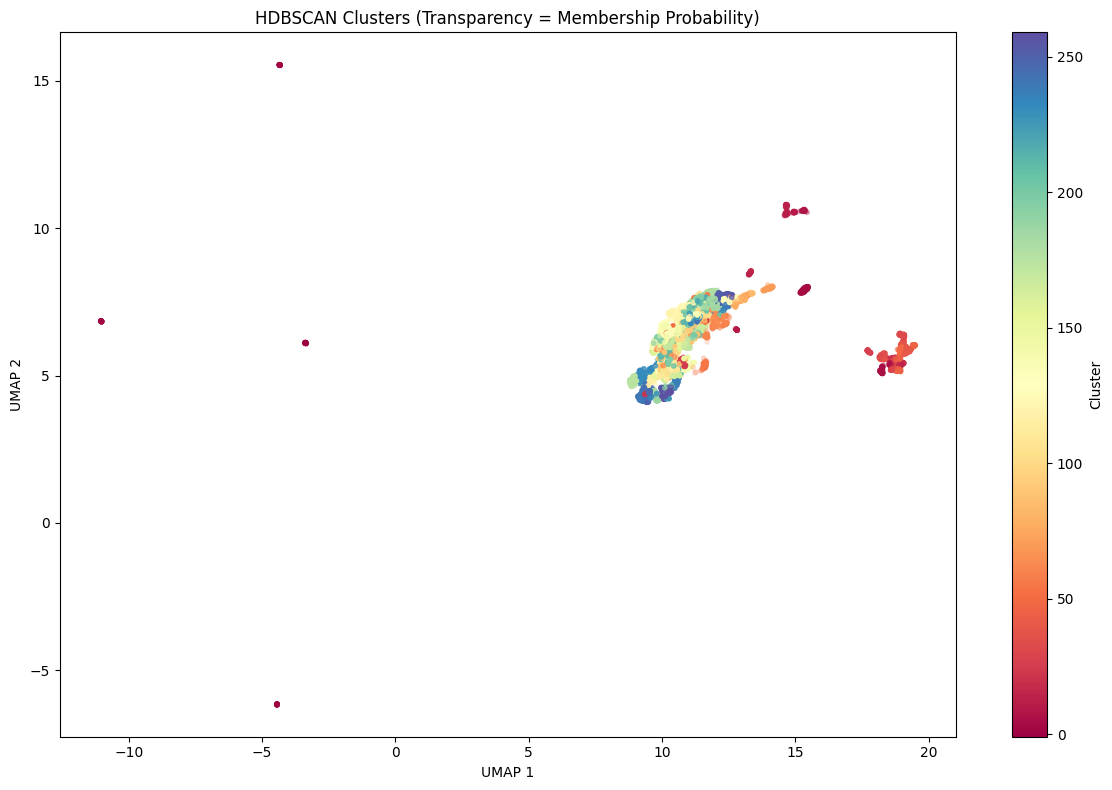

In [8]:
# HDBSCAN provides membership probabilities and outlier scores
df['cluster_probability'] = clusterer.probabilities_
df['outlier_score'] = clusterer.outlier_scores_

print("Cluster membership probabilities:")
print(df[['calltype', 'cluster', 'cluster_probability', 'outlier_score']].head(10))

# Visualize with probability-based transparency
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    X_umap[:, 0], 
    X_umap[:, 1], 
    c=cluster_labels,
    cmap='Spectral',
    s=10,
    alpha=clusterer.probabilities_  # Alpha based on membership probability
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('HDBSCAN Clusters (Transparency = Membership Probability)')
plt.tight_layout()
plt.show()

## HDBSCAN Clustering